In [1]:
from common_functions import *
from matplotlib import gridspec
from scipy.integrate import quad

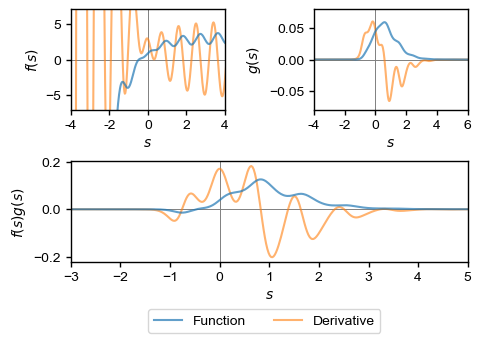

In [2]:
set_rcParams()

# figure dimensions
fig_height = 3    # height (in inches)
fig_width  = 4.7  # width (in inches)

# initialize figure
fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)

grid  = fig.add_gridspec(2, 2)
ax1   = fig.add_subplot(grid[0,0])
ax2   = fig.add_subplot(grid[0,1])
ax3   = fig.add_subplot(grid[1,:])

def f_func(s, b, g, d, A, p, w, x0):
    a = 2 * np.pi * (s / d + p) / w
    F = 1 + A * np.cos(a)
    x = 1 - (1 - x0) * np.exp(-s)
    return (b * F * x + g)
def B_func(s, b, g, d, A, p, w, x0):
    a = 2 * np.pi * (s / d + p) / w
    B = (b * (A * w * (d * w * np.cos(a) - 2 * np.pi * np.sin(a)) / ((d * w)**2 + (2 * np.pi)**2) + 1 / d) * (1 - x0) * np.exp(-s)
                       + (b - g) * s / d + A * b * w * np.sin(a) / (2 * np.pi))
    return B
def g_func(s, b, g, d, A, p, w, x0):
    B = B_func(s, b, g, d, A, p, w, x0)
    return np.exp(-B)

t_max = 15; t_min = -10
taus = np.linspace(t_min, t_max, 1000)

b  = 2.2
g  = 0.8
d  = 0.7
A  = 0.35
p  = 0
w  = 1.3
x0 = 0.02

fs = f_func(taus, b, g, d, A, p, w, x0)
gs = g_func(taus, b, g, d, A, p, w, x0)

integrand = lambda s: f_func(s, b, g, d, A, p, w, x0) * g_func(s, b, g, d, A, p, w, x0)

dfdt = np.gradient(fs, taus)
ax1.plot(taus, fs, zorder=1, alpha=0.7, label='Function')
ax1.plot(taus, dfdt, zorder=0, alpha=0.6, label='Derivative')
ax1.set_xlim([-4, 4])
ax1.set_ylim([-7,7])
ax1.axhline(y=0, color='gray', linewidth=0.7, zorder=-1)
ax1.axvline(x=0, color='gray', linewidth=0.7, zorder=-1)
ax1.set_ylabel('$f(s)$')
ax1.set_xlabel('$s$')
ax1.set_xticks([-4,-2,0,2,4],[-4,-2,0,2,4])

dgdt = np.gradient(gs, taus)
ax2.plot(taus, gs, zorder=1, alpha=0.7, label='Function')
ax2.plot(taus, dgdt, zorder=0, alpha=0.6, label='Derivative')
ax2.set_xlim([-4, 6])
ax2.set_ylim([-0.08,0.08])
ax2.axhline(y=0, color='gray', linewidth=0.7, zorder=-1)
ax2.axvline(x=0, color='gray', linewidth=0.7, zorder=-1)
ax2.set_ylabel('$g(s)$')
ax2.set_xlabel('$s$')
ax2.set_xticks([-4,-2,0,2,4,6],[-4,-2,0,2,4,6])

fsgs  = fs * gs
dfgdt = np.gradient(fsgs, taus)
ax3.plot(taus, fsgs, zorder=1, alpha=0.7, label='Function')
ax3.plot(taus, dfgdt, zorder=0, alpha=0.6, label='Derivative')
ax3.axhline(y=0, color='gray', linewidth=0.7, zorder=-1)
ax3.axvline(x=0, color='gray', linewidth=0.7, zorder=-1)
ax3.set_xlim([-3, 5])
ax3.set_ylabel('$f(s)g(s)$')
ax3.set_xlabel('$s$')

# legend stuff
unique_label_legend(fig) # defined in `common_functions.py`

# save figure
plt.savefig("plots/lims_at_inf.pdf", bbox_inches="tight", dpi=600)

Text(0.5, 0, '$T$')

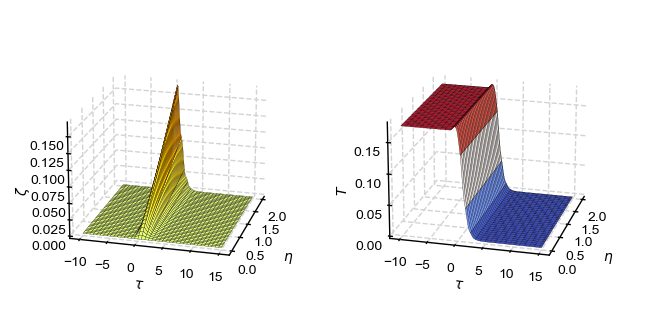

In [3]:
N = 2

fig, ax = plt.subplots(1, 2, subplot_kw={"projection": "3d"})

n_taus = 200
n_etas = 200
taus   = np.linspace(t_min, t_max, n_taus)
etas   = np.linspace(0, N * 0.99, n_etas)

TAUs, ETAs = np.meshgrid(taus, etas)
ZETA       = 2 / (N * d) * ETAs * np.exp(-B_func(TAUs, b, g, d, A, p, w, x0))
Ts         = np.zeros((n_taus, n_etas))
for i in range(len(TAUs[0])):
    tau     = TAUs[0][i]
    T, err  = quad(lambda s: integrand(s) / (N * d**2), tau, np.inf)
    Ts[:,i] = T

ax[1].plot_surface(TAUs, ETAs, Ts, cmap='coolwarm', rstride=7, cstride=7, edgecolor="black", linewidth=0.2)
ax[0].plot_surface(TAUs, ETAs, ZETA, cmap='Wistia', rstride=5, cstride=5, edgecolor="black", linewidth=0.2)

for i in [0,1]:
    # make background transparent
    ax[i].xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax[i].yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax[i].zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    
    ax[i].set_xlabel(r'$\tau$')
    ax[i].yaxis.set_rotate_label(False)  # disable automatic rotation
    ax[i].set_ylabel(r'$\eta$', labelpad=10)
    ax[i].zaxis._axinfo['juggled'] = (1,2,0) # z-axis left side
    ax[i].zaxis.set_rotate_label(False)  # disable automatic rotation
    
    # set viewing angle
    ax[i].view_init(azim=-75, elev=20)
    
    # fixes labels getting cut off
    ax[i].set_box_aspect(None, zoom=0.80)

ax[0].set_zlabel(r'$\zeta$', rotation=-270)
ax[1].set_zlabel(r'$T$', rotation=-270)

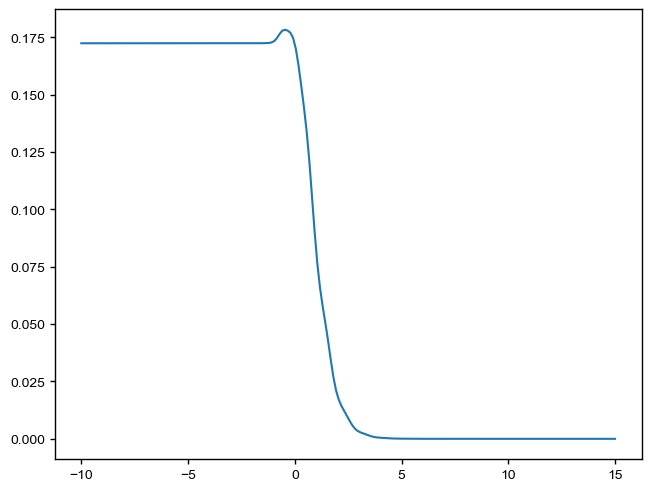

In [4]:
plt.plot(taus, Ts[0,:])